In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import h5py
import scipy.sparse as sp
import yaml
import scanpy as sc
import anndata as an
import scanpy.external as sce
import gget
import time
import pyranges as pr
from scipy.stats import ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests

import logging
sc.settings.verbosity = 2

In [5]:
start = time.perf_counter()

path = "/scratch/indikar_root/indikar1/shared_data/HYB/anndata/isoforms.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata

Memory usage: current 2.15 GB, difference +0.50 GB
Total time: 0.46 seconds


AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

# Filter cells based on gene data

In [6]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"
# path = "/scratch/indikar_root/indikar1/shared_data/HYB/anndata/condition_subsets/pos_myod.h5ad"

gdata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

gdata

Memory usage: current 4.07 GB, difference +1.92 GB
Total time: 4.89 seconds


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

In [7]:
coords = pd.DataFrame({
    'cell_id' : gdata.obs.index,
    'UMAP 1' : gdata.obsm['X_umap'][:, 0],
    'UMAP 2' : gdata.obsm['X_umap'][:, 1],
    # 'FA_1' : gdata.obsm['X_draw_graph_fa'][:, 0],
    # 'FA_2' : gdata.obsm['X_draw_graph_fa'][:, 1],
    'cluster' : gdata.obs['cluster_str'].values,
    #'dataset': adata.obs['dataset'].values,
    'pooled_condition': gdata.obs['pooled_condition'].values,
})

coords = coords.set_index('cell_id') # Set cell_id as the index for joining with bdata.obs
print(f"{coords.shape=}")

coords_hyb = coords[coords.index.str.endswith('_hybrid')]
print(f"\nN cells in Hybrid: {coords_hyb.shape[0]}")

coords_fib = coords[coords.index.str.endswith('_control')]
print(f"N cells in scFib: {coords_fib.shape[0]}")

coords.head()

coords.shape=(16367, 4)

N cells in Hybrid: 9407
N cells in scFib: 6960


,UMAP 1,UMAP 2,cluster,pooled_condition
cell_id,,,,
AAACCAAAGCAACTGC_hybrid,7.094635,4.097683,C1,siPRRX1/mmMYOD1
AAACCAAAGTAGGGCA_hybrid,5.200652,5.790956,C1,mmMYOD1
AAACCAAAGTCTAGGC_hybrid,3.396403,6.577598,C2,siPRRX1/mmMYOD1
AAACCATTCACGTAAT_hybrid,10.489384,9.934184,C4,siPRRX1
AAACCATTCAGGCAGA_hybrid,10.483599,9.203198,C4,siPRRX1


In [5]:
### --- Filter for cells in gene data ---
common_cells = adata.obs.index.intersection(coords.index)
print(f"Overlapping cells: {len(common_cells)}")

adata = adata[common_cells].copy()

adata.obs = adata.obs.join(coords.loc[common_cells])

print(f"Isoform data subsetted. New shape: {adata.shape}")

# Get total counts per transcript
adata.var['transcript_counts'] = np.asarray(adata.X.sum(axis=0)).ravel()

print(adata.obs['dataset'].value_counts())

adata

Overlapping cells: 12388
Isoform data subsetted. New shape: (12388, 89570)
dataset
Control    6872
Hybrid     5516
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 12388 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts', 'FA_1', 'FA_2', 'cluster', 'pooled_condition'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'transcript_counts'

In [6]:
# # Simple filtering
# sc.pp.filter_genes(adata, min_counts=50)

# adata

filtered out 47007 genes that are detected in less than 50 counts


AnnData object with n_obs × n_vars = 16367 × 42563
    obs: 'dataset', 'n_reads', 'n_transcripts', 'UMAP 1', 'UMAP 2', 'cluster', 'pooled_condition'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'transcript_counts', 'n_counts'

In [6]:
cluster_names = [f"C{i}" for i in range(1, 6)]
cluster_names

['C1', 'C2', 'C3', 'C4', 'C5']

In [7]:
adata.layers['counts'] = adata.X.copy()

# cluster_names = ['Control', 'siPRRX1', 'mmMYOD1', 'siPRRX1/mmMYOD1']
cluster_names = [f"C{i}" for i in range(1, 6)]
# print(f"Using {cluster_names}...\n")

# cluster_map = {
#     'C1': 'Rest',
#     'C2': 'Rest',
#     'C3': 'C3C4',
#     'C4': 'C3C4',
#     'C5': 'Rest',
#     'C6': 'Rest',
# }

# adata.obs['cluster_group'] = adata.obs['cluster'].map(cluster_map)

cdf = adata.var.copy()
print(f"All transcript types: {cdf.shape}")



# cdf = cdf[(cdf['transcript_type'] == 'protein_coding') & (~cdf['UniProtKB'].isna())].copy()
# print(f"Protein-coding and non-NaN UniprotKB: {cdf.shape}")

# print(cdf['transcript_type'].value_counts())

for group in cluster_names:
    # Boolean mask of cells in the group
    # mask = adata_raw.obs['cluster'] == group
    mask = adata.obs['cluster'] == group
    
    # Get the indices of protein-coding genes with non-NaN UniprotKB in adata.var
    # filtered_gene_indices = adata_raw.var[(adata_raw.var['transcript_type'] == 'protein_coding') & (~adata.var['UniProtKB'].isna())].index

    # Sum counts across those cells, but only for the filtered genes
    summed_counts = adata[mask, :].layers['counts'].sum(axis=0)    
    
    ## Sum counts across those cells
    # summed_counts = adata[mask].layers['counts'].sum(axis=0)
    
    # Convert to 1D array (if sparse or matrix)
    summed_counts = np.array(summed_counts).flatten()
    
    # Add as a new column
    cdf[group] = summed_counts
    
    cdf[f"{group}_gene_counts"] = cdf.groupby('gene_name', observed=True)[group].transform('sum')
    cdf[f"{group}_transcript_pct"] = cdf[group] / cdf[f"{group}_gene_counts"]
    
cdf = cdf.sort_values(by='gene_name')


# cdf['Rest_gene_counts'] = cdf.groupby('gene_name', observed=True)['Rest'].transform('sum')
# cdf['C3C4_gene_counts'] = cdf.groupby('gene_name', observed=True)['C3C4'].transform('sum')

# cdf['Rest_transcript_pct'] = cdf['Rest'] / cdf['Rest_gene_counts']
# cdf['C3C4_transcript_pct'] = cdf['C3C4'] / cdf['C3C4_gene_counts']

# cdf['pct_diff'] = cdf['C3C4_transcript_pct'] - cdf['Rest_transcript_pct']

print(cdf.shape)
cdf.head()

All transcript types: (89570, 11)
(89570, 26)


,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,...,C2_transcript_pct,C3,C3_gene_counts,C3_transcript_pct,C4,C4_gene_counts,C4_transcript_pct,C5,C5_gene_counts,C5_transcript_pct
ENST00000598345,ENSG00000121410,A1BG,protein_coding,A1BG-204,retained_intron,chr19,58346859,58347657,ENST00000598345,NaN,...,0.990917,3135,3146,0.996503,3112,3115,0.999037,171,172,0.994186
ENST00000596924,ENSG00000121410,A1BG,protein_coding,A1BG-203,protein_coding_CDS_not_defined,chr19,58345177,58347634,ENST00000596924,NaN,...,0.008174,7,3146,0.002225,2,3115,0.000642,1,172,0.005814
ENST00000600966,ENSG00000121410,A1BG,protein_coding,A1BG-205,protein_coding,chr19,58350593,58353129,ENST00000600966,M0R009,...,0.000908,4,3146,0.001271,1,3115,0.000321,0,172,0.000000
ENST00000670460,ENSG00000268895,A1BG-AS1,lncRNA,A1BG-AS1-209,lncRNA,chr19,58347717,58355455,ENST00000670460,NaN,...,0.600000,43,136,0.316176,32,105,0.304762,9,32,0.281250
ENST00000593960,ENSG00000268895,A1BG-AS1,lncRNA,A1BG-AS1-202,lncRNA,chr19,58347746,58355186,ENST00000593960,NaN,...,0.029630,19,136,0.139706,19,105,0.180952,2,32,0.062500


# Identify isoform switches

In [8]:
def identify_dominant_isoform_switch_multiple_conditions(
    df: pd.DataFrame,
    condition_prefixes: list[str],
    count_threshold: int = 10,
) -> pd.DataFrame:
    """
    Identifies genes with a switch in the dominant isoform across multiple conditions,
    where the dominant isoform accounts for > 50% of transcript counts in its condition,
    and the gene has >= count_threshold total counts in all conditions.

    Returns all transcripts for genes that meet the criteria for at least one pairwise switch.
    """
    if len(condition_prefixes) < 2:
        raise ValueError("At least two condition prefixes are required.")

    # Define relevant column name patterns
    gene_counts_cols = [f'{prefix}_gene_counts' for prefix in condition_prefixes]
    transcript_pct_cols = [f'{prefix}_transcript_pct' for prefix in condition_prefixes]

    # Step 1: Identify genes that meet the count threshold in all conditions
    # Using observed=True to silence the FutureWarning and ensure correct behavior with categorical data
    gene_totals = df.groupby('gene_id', observed=True)[gene_counts_cols].sum()
    valid_genes = gene_totals[
        (gene_totals[gene_counts_cols] >= count_threshold).all(axis=1)
    ].index

    df_filtered = df[df['gene_id'].isin(valid_genes)].copy()
    if df_filtered.empty:
        print("df_filtered is empty after filtering by valid_genes.")
        return pd.DataFrame(columns=df.columns)

    dominant_isoforms = {}
    for i, prefix in enumerate(condition_prefixes):
        transcript_pct_col = transcript_pct_cols[i]
        # Sort values before grouping to ensure iloc[0] consistently gets the 'dominant' one
        # Using observed=True for groupby
        dominant_condition = (
            df_filtered.sort_values(by=['gene_id', transcript_pct_col], ascending=[True, False])
            .groupby('gene_id', observed=True)
            .apply(
                lambda x: x.iloc[0][['transcript_id', 'UniProtKB', transcript_pct_col]]
                if not x.empty and x.iloc[0][transcript_pct_col] > 0.5
                else pd.Series({'transcript_id': None, 'UniProtKB': None, transcript_pct_col: None})
            )
            .reset_index()
        )
        dominant_isoforms[prefix] = dominant_condition

    switching_genes = set()
    # Step 3: Compare all pairs of conditions to identify switches
    for i in range(len(condition_prefixes)):
        for j in range(i + 1, len(condition_prefixes)):
            prefix1 = condition_prefixes[i]
            prefix2 = condition_prefixes[j]
            transcript_pct_col1 = transcript_pct_cols[i]
            transcript_pct_col2 = transcript_pct_cols[j]

            merged = pd.merge(
                dominant_isoforms[prefix1][['gene_id', 'transcript_id', 'UniProtKB', transcript_pct_col1]],
                dominant_isoforms[prefix2][['gene_id', 'transcript_id', 'UniProtKB', transcript_pct_col2]],
                on='gene_id',
                suffixes=(f'_{prefix1}', f'_{prefix2}'),
            )

            switch_transcript = merged[
                (merged[f'transcript_id_{prefix1}'].notna()) &
                (merged[f'transcript_id_{prefix2}'].notna()) &
                (merged[f'transcript_id_{prefix1}'] != merged[f'transcript_id_{prefix2}'])
            ]

            switch_uniprot = switch_transcript[
                (~switch_transcript[f'UniProtKB_{prefix1}'].isna()) &
                (~switch_transcript[f'UniProtKB_{prefix2}'].isna())
            ]

            pairwise_switching_genes = switch_uniprot[
                switch_uniprot[f'UniProtKB_{prefix1}'] != switch_uniprot[f'UniProtKB_{prefix2}']
            ]['gene_id'].unique()

            switching_genes.update(pairwise_switching_genes)

    return df[df['gene_id'].isin(switching_genes)].copy()

In [9]:
# Get only protein-coding transcripts 
tmp = cdf[cdf['UniProtKB'].notna()].copy()

switch_df = identify_dominant_isoform_switch_multiple_conditions(
    tmp, 
    condition_prefixes=cluster_names, 
    count_threshold=50
)

switch_df['gene_counts_total'] = switch_df.filter(like='_gene_counts', axis=1).sum(axis=1)
switch_df['gene_counts_std'] = switch_df.filter(like='_gene_counts', axis=1).std(axis=1)

print(switch_df.shape)
switch_df.head()

/tmp/ipykernel_511631/3987351224.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_511631/3987351224.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_511631/3987351224.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from

(1071, 28)


/tmp/ipykernel_511631/3987351224.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,...,C3_gene_counts,C3_transcript_pct,C4,C4_gene_counts,C4_transcript_pct,C5,C5_gene_counts,C5_transcript_pct,gene_counts_total,gene_counts_std
ENST00000423487,ENSG00000165029,ABCA1,protein_coding,ABCA1-203,protein_coding,chr9,104855565,104928139,ENST00000423487,B1AMI2,...,59,0.067797,2,54,0.037037,3,72,0.041667,612,103.025725
ENST00000374736,ENSG00000165029,ABCA1,protein_coding,ABCA1-202,protein_coding,chr9,104781005,104928155,ENST00000374736,O95477,...,59,0.491525,21,54,0.388889,62,72,0.861111,612,103.025725
ENST00000678995,ENSG00000165029,ABCA1,protein_coding,ABCA1-205,protein_coding,chr9,104781006,104928155,ENST00000678995,A0A7I2V5U0,...,59,0.440678,31,54,0.574074,7,72,0.097222,612,103.025725
ENST00000645843,ENSG00000164074,ABHD18,protein_coding,ABHD18-206,protein_coding,chr4,127965405,128039953,ENST00000645843,A0A2R8YEZ0,...,139,0.546763,53,94,0.563830,2,10,0.200000,462,53.696369
ENST00000444616,ENSG00000164074,ABHD18,protein_coding,ABHD18-202,protein_coding,chr4,127965376,128031313,ENST00000444616,Q0P651,...,139,0.057554,3,94,0.031915,1,10,0.100000,462,53.696369


In [10]:
switch_df = switch_df.sort_values(by=['gene_counts_total', 'gene_counts_std'], ascending=[False, True])
switch_df.head()

,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,...,C3_gene_counts,C3_transcript_pct,C4,C4_gene_counts,C4_transcript_pct,C5,C5_gene_counts,C5_transcript_pct,gene_counts_total,gene_counts_std
ENST00000229281,ENSG00000111678,C12orf57,protein_coding,C12orf57-201,protein_coding,chr12,6944021,6946002,ENST00000229281,Q99622,...,29404,0.792477,20161,25990,0.775721,642,1904,0.337185,72204,12599.476922
ENST00000544681,ENSG00000111678,C12orf57,protein_coding,C12orf57-206,protein_coding,chr12,6943816,6945098,ENST00000544681,U3KQ07,...,29404,0.000476,11,25990,0.000423,164,1904,0.086134,72204,12599.476922
ENST00000537087,ENSG00000111678,C12orf57,protein_coding,C12orf57-202,protein_coding,chr12,6943833,6946002,ENST00000537087,F5GXW5,...,29404,0.206775,5812,25990,0.223624,1096,1904,0.575630,72204,12599.476922
ENST00000475836,ENSG00000163584,RPL22L1,protein_coding,RPL22L1-204,nonsense_mediated_decay,chr3,170866262,170870195,ENST00000475836,Q5JWX6,...,10693,0.004395,41,6651,0.006164,1040,1556,0.668380,29891,3326.067152
ENST00000295830,ENSG00000163584,RPL22L1,protein_coding,RPL22L1-201,protein_coding,chr3,170864874,170870195,ENST00000295830,Q6P5R6,...,10693,0.031142,202,6651,0.030371,41,1556,0.026350,29891,3326.067152


In [16]:
switch_df.sort_values(by=['gene_counts_std', 'gene_counts_total'], ascending=[True, False]).head()

,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,...,C3_gene_counts,C3_transcript_pct,C4,C4_gene_counts,C4_transcript_pct,C5,C5_gene_counts,C5_transcript_pct,gene_counts_total,gene_counts_std
ENST00000239367,ENSG00000120256,LRP11,protein_coding,LRP11-201,protein_coding,chr6,149818756,149864359,ENST00000239367,Q86VZ4,...,34,0.558824,21,30,0.700000,1,26,0.038462,171,6.870226
ENST00000367368,ENSG00000120256,LRP11,protein_coding,LRP11-202,protein_coding,chr6,149840437,149864026,ENST00000367368,Q5VYB9,...,34,0.323529,7,30,0.233333,10,26,0.384615,171,6.870226
ENST00000455537,ENSG00000155980,KIF5A,protein_coding,KIF5A-202,protein_coding,chr12,57550043,57586633,ENST00000455537,Q12840,...,16,0.312500,6,13,0.461538,0,16,0.000000,93,7.092249
ENST00000674619,ENSG00000155980,KIF5A,protein_coding,KIF5A-204,protein_coding,chr12,57550026,57586630,ENST00000674619,A0A6Q8PGJ3,...,16,0.500000,7,13,0.538462,2,16,0.125000,93,7.092249
ENST00000675216,ENSG00000155980,KIF5A,protein_coding,KIF5A-211,nonsense_mediated_decay,chr12,57550043,57563693,ENST00000675216,A0A6Q8PHA9,...,16,0.000000,0,13,0.000000,0,16,0.000000,93,7.092249


In [17]:
switch_df.columns

Index(['gene_id', 'gene_name', 'gene_type', 'transcript_name',
       'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id',
       'UniProtKB', 'transcript_counts', 'C1', 'C1_gene_counts',
       'C1_transcript_pct', 'C2', 'C2_gene_counts', 'C2_transcript_pct', 'C3',
       'C3_gene_counts', 'C3_transcript_pct', 'C4', 'C4_gene_counts',
       'C4_transcript_pct', 'C5', 'C5_gene_counts', 'C5_transcript_pct',
       'gene_counts_total', 'gene_counts_std'],
      dtype='object')

In [56]:
# add column for HYB gene counts
switch_df['gene_counts_HYB'] = switch_df.filter(like='1_gene_counts', axis=1).sum(axis=1)

switch_df['count_diff'] = abs(switch_df['gene_counts_HYB'] - switch_df['Control_gene_counts'])

switch_df[['gene_name', 'gene_counts_HYB', 'Control_gene_counts', 'count_diff']].head()

,gene_name,gene_counts_HYB,Control_gene_counts,count_diff
ENST00000530028,EID1,39359,5705,33654
ENST00000560490,EID1,39359,5705,33654
ENST00000295688,CCT3,20219,17686,2533
ENST00000472765,CCT3,20219,17686,2533
ENST00000368262,CCT3,20219,17686,2533


In [78]:
# switch_df.sort_values(by=['gene_counts_HYB', 'count_diff'], ascending=[False, True])[['gene_name', 'gene_counts_HYB', 'Control_gene_counts', 'count_diff']].head()
top_genes = switch_df.sort_values(by=['gene_counts_HYB', 'count_diff'], ascending=[False, True])['gene_name'].unique()[:20]
print(", ".join(top_genes))

EID1, CCT3, SKP1, NT5E, RGMB, EHBP1, UBE2B, ZFAND3, MGLL, SRGAP1, PPP1R14B, DYNLT2B, PET100, DOCK5, APPL2, C12orf43, MPC1, TNS3, MAP4K5, PCNX4


# Load in marker genes

In [11]:
fpath = "../../resources/liu_core_genes.csv"

df = pd.read_csv(fpath)

df.head()

,Fibroblast,Muscle,Circadian,Cell Cycle
0,AKT1,ACTN3,ARNTL,CCNA1
1,API5,ANKRD1,ARNTL2,CCNA2
2,BAG4,ANKRD33,BHLHE41,CCNB1
3,BAK1,BCL9,CLOCK,CCNB2
4,BMI1,BHLHE41,CREBBP,CCNC


In [12]:
def find_overlapping_genes_in_df_columns(df: pd.DataFrame, query_genes: list[str]) -> dict:

    query_genes_set = set(query_genes)

    results_by_column = {}

    for col_name in df.columns:
        genes_in_column = df[col_name].dropna().unique()
        genes_in_column_set = set(genes_in_column)

        overlap = [gene for gene in query_genes if gene in genes_in_column_set]
        results_by_column[col_name] = overlap

        print(f"{col_name}: {len(overlap)} overlapping genes")
        if overlap:
            print(f"Overlapping genes: {overlap}")
        else:
            print("No overlapping genes found.")
        print()

        
isoforms = switch_df.sort_values(by=['gene_counts_total', 'gene_counts_std'], ascending=[False, True])['gene_name'].unique()
        
find_overlapping_genes_in_df_columns(df, isoforms)

Fibroblast: 0 overlapping genes
No overlapping genes found.

Muscle: 0 overlapping genes
No overlapping genes found.

Circadian: 1 overlapping genes
Overlapping genes: ['PER1']

Cell Cycle: 2 overlapping genes
Overlapping genes: ['CCNT2', 'CDC34']



In [13]:
# load tf list
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
print(len(tf_list))

print([gene for gene in tf_list if gene in isoforms])

1892
['ETV4', 'TFCP2', 'HOXA9', 'HSF1', 'RUNX2', 'KLF2', 'ZNF3', 'ZNF561', 'ZNF431', 'ZNF616', 'IRF1', 'KLF7', 'ZNF490', 'SMAD4', 'STAT6', 'PURA', 'MYEF2', 'CCNT2', 'ZNF746', 'ZBTB34', 'AEBP2', 'FIZ1', 'ZNF20', 'ZNF66', 'ZNF710', 'ZNF92', 'ZNF773', 'ZNF606', 'TERF2', 'ADNP2', 'FBXL19', 'KDM4A', 'POLI', 'RUVBL1', 'TIGD7', 'UQCRB', 'ZC3H7A']


In [28]:
fpath = "../../resources/clean_marker_genes.csv"

mdf = pd.read_csv(fpath)

mdf.head()

,gene_name,cell_type,is_tf,source,category
0,LUM,airway_smooth_muscle_cells,False,panglao,muscle
1,COL1A1,airway_smooth_muscle_cells,False,panglao,muscle
2,COL5A2,airway_smooth_muscle_cells,False,panglao,muscle
3,COL5A1,airway_smooth_muscle_cells,False,panglao,muscle
4,FNDC1,airway_smooth_muscle_cells,False,panglao,muscle


In [37]:
def find_overlapping_genes_by_category(mdf: pd.DataFrame, query_genes: list[str]) -> dict:
    query_genes_set = set(query_genes)

    results_by_category = {}

    # Iterate through each unique category in the 'category' column.
    for category_name in mdf['category'].unique():
        # Get gene names for the current category, dropping NaN values.
        genes_in_category = mdf[mdf['category'] == category_name]['gene_name'].dropna().unique()
        # Convert genes in category to a set for efficient lookup.
        genes_in_category_set = set(genes_in_category)

        # Find the intersection (overlap) between query_genes and genes in the current category.
        overlap = [gene for gene in query_genes if gene in genes_in_category_set]
        results_by_category[category_name] = overlap

        # Print the output in the desired format for each category.
        print(f"{category_name}: {len(overlap)} overlapping genes")
        if overlap:
            print(f"Overlapping genes: {overlap}")
        else:
            print("No overlapping genes found.")
        print() # Add a blank line for spacing.

find_overlapping_genes_by_category(mdf, isoforms)

muscle: 10 overlapping genes
Overlapping genes: ['COL5A1', 'UQCRB', 'ACTA2', 'ABI3BP', 'COX7B', 'PLAT', 'HTRA1', 'FBXL7', 'ADGRL4', 'KLF2']

myocyte: 1 overlapping genes
Overlapping genes: ['DOCK5']

fibroblast: 10 overlapping genes
Overlapping genes: ['NT5E', 'COL5A1', 'ACTA2', 'IL1R1', 'ABI3BP', 'NFKB1', 'HTRA1', 'LRRK1', 'ADGRL4', 'KLF2']

myoblast: 5 overlapping genes
Overlapping genes: ['COL5A1', 'HSPG2', 'HTRA1', 'FBXL7', 'ANGPT2']

myofibroblast: 6 overlapping genes
Overlapping genes: ['COL5A1', 'ACTA2', 'NTM', 'HTRA1', 'FBXL7', 'ADGRL4']

ipsc: 1 overlapping genes
Overlapping genes: ['MCM10']

skeletal_muscle: 1 overlapping genes
Overlapping genes: ['ACTA2']



In [14]:
fpath = "../../resources/quiescence_markers.csv"

qdf = pd.read_csv(fpath)

qui_genes = qdf['gene'].unique()
print(f"N quiescence genes: {len(qui_genes)}")

print([gene for gene in qui_genes if gene in isoforms])

N quiescence genes: 193
['IL1R1', 'PLAT', 'TNC', 'ACTA2']


In [81]:
# switch_df.sort_values(by=['gene_counts_HYB', 'count_diff'], ascending=[False, True])[['gene_name', 'gene_counts_HYB', 'Control_gene_counts', 'count_diff']].head()
top_genes = switch_df.sort_values(by=['gene_counts_HYB', 'count_diff'], ascending=[False, True])['gene_name'].unique()[:50]
print(", ".join(top_genes))

EID1, CCT3, SKP1, NT5E, RGMB, EHBP1, UBE2B, ZFAND3, MGLL, SRGAP1, PPP1R14B, DYNLT2B, PET100, DOCK5, APPL2, C12orf43, MPC1, TNS3, MAP4K5, PCNX4, PURA, IRF1, TMED4, NEMF, SRPK2, TAF13, CWC22, ECPAS, NUP85, TMEM245, UBE2M, TJP1, FCF1, SCAF8, FAT1, IL1R1, CPLANE1, CLTC, UQCRB, PDIA4, PRKCSH, COL5A1, RPUSD3, ARHGEF18, NBPF14, EXOC6B, TNC, NFKB1, PACS1, GOSR1


In [33]:
top_genes = switch_df['gene_name'].unique()[:200]
print(", ".join(top_genes))

C12orf57, RPL22L1, CCT3, EID1, UBE2B, RGMB, SKP1, IRF1, NT5E, MDH2, SNRPA1, TNC, PPP1R14B, PET100, EHBP1, SLC38A1, DYNLT2B, RUVBL1, UQCRB, CHMP4A, CWC22, MPC1, ZFAND3, MATR3, HOXA9, TAF13, DOCK5, MGLL, SRGAP1, SRP19, NDUFB5, NAV1, TMED4, ACTA2, MITD1, GOSR1, PRKCA, DNAJC8, NTM, FAT1, ZMAT3, PIH1D1, MRPS5, PURA, ASAP1, SDAD1, APPL2, C12orf43, MAP4K5, GOLGA4, ECI2, U2SURP, TNS3, IL1R1, PTAR1, NUP85, MAP1LC3B, ROBO1, PCNX4, HAPSTR1, PRKCSH, FCF1, AP1AR, CETN3, MTHFS, TJP1, STIM2, ZCCHC2, IDH3B, CHPT1, FAM200A, SLC15A3, ABI3BP, SCAF8, STX3, FBXL17, SNX6, CHRNB1, RPUSD3, UBE2M, IGFLR1, TMEM245, RETREG3, C17orf75, SNUPN, DPY19L4, CUL4A, SEH1L, STAT6, GPAA1, C3, MAP3K8, FAM193A, ATPAF1, CPLANE1, HSF1, COX7B, ARHGEF18, EXOC6B, TFCP2, RBKS, SHOC1, DUSP12, CHTF8, GATD1, ZNFX1, RRP8, FARP2, MAP3K5, DCLK2, NBPF14, MTMR9, APOO, NISCH, PACS1, ANGPTL1, MOB3A, KCNN2, CWC25, DHRS1, RETREG2, ALG11, SLC30A9, UNK, PARVB, PLAT, ZNF431, ARHGEF2, FBXL15, ORAI3, AEBP2, USP37, ZNF710, DMXL1, DENND4C, SLMAP, AD

In [86]:
query = 'ARHGEF2'

tmp[tmp['gene_name'] == query]

,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,...,C2_transcript_pct,C3,C3_gene_counts,C3_transcript_pct,C4,C4_gene_counts,C4_transcript_pct,C5,C5_gene_counts,C5_transcript_pct
ENST00000497907,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-216,protein_coding,chr1,155964987,155978169,ENST00000497907,V9GYG5,...,0.011086,5,134,0.037313,7,178,0.039326,5,151,0.033113
ENST00000471589,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-210,protein_coding,chr1,155963139,155979099,ENST00000471589,V9GZ14,...,0.000000,17,134,0.126866,15,178,0.084270,0,151,0.000000
ENST00000495070,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-215,protein_coding,chr1,155969247,155989499,ENST00000495070,V9GY94,...,0.002217,0,134,0.000000,0,178,0.000000,1,151,0.006623
ENST00000313667,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-201,protein_coding,chr1,155947941,155978427,ENST00000313667,Q92974,...,0.000000,3,134,0.022388,0,178,0.000000,0,151,0.000000
ENST00000696600,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-220,nonsense_mediated_decay,chr1,155946921,155972349,ENST00000696600,A0A8Q3SIV8,...,0.700665,14,134,0.104478,10,178,0.056180,71,151,0.470199
ENST00000673475,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-219,protein_coding,chr1,155946854,155991212,ENST00000673475,A0A5F9ZI21,...,0.135255,64,134,0.477612,118,178,0.662921,56,151,0.370861
ENST00000470874,ENSG00000116584,ARHGEF2,protein_coding,ARHGEF2-208,nonsense_mediated_decay,chr1,155963126,155966479,ENST00000470874,V9GZ58,...,0.000000,18,134,0.134328,14,178,0.078652,0,151,0.000000


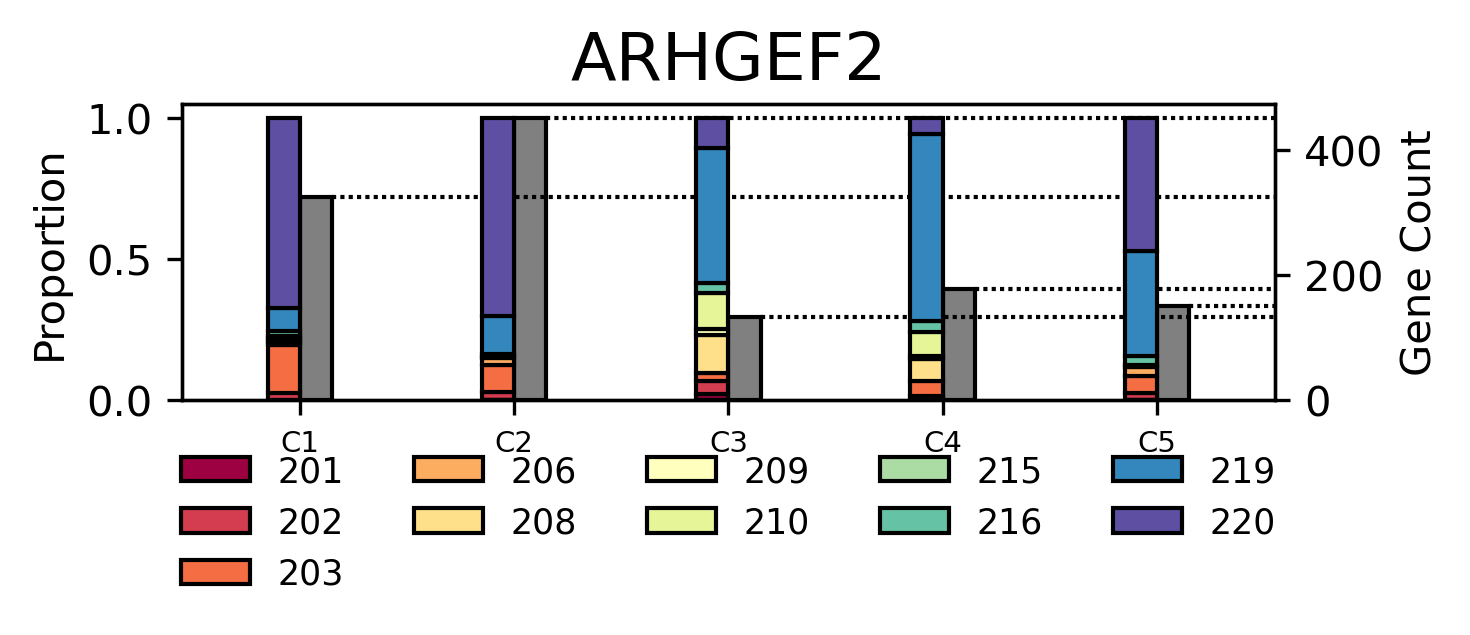

In [87]:
width = 0.15  # Adjust width for more bars
nudge = 0.05 #0.03
color = 'grey'

"""
DATA SET UP
"""
pdf = cdf.copy()
pdf = pdf[pdf['gene_name'] == query]

pdf = pdf.sort_values(by='transcript_name')
pdf = pdf.set_index('transcript_name')

# Get total counts for the gene for each condition
count_cols = [f'{cond}' for cond in cluster_names]
counts = pdf[count_cols].sum(axis=0)

# Get transcript percentages for each condition
pct_cols = [f'{cond}_transcript_pct' for cond in cluster_names]
pdf_pct = pdf[pct_cols]
pdf_pct = pdf_pct[pdf_pct.sum(axis=1) != 0]  # Drop zero-sum transcripts !

pdf_pct.columns = pdf_pct.columns.map(lambda x: x.split("_")[0])
pdf_pct = pdf_pct.T
pdf_pct

"""
PLOT
"""
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 1 * len(cluster_names), 3.5  # Adjust figure width
fig, ax1 = plt.subplots()

# Create a second axis for the count bar plot
ax2 = ax1.twinx()

# Plot gene counts
ax2.bar(
    counts.index,
    counts.values,
    color=color,
    ec='k',
    alpha=1,
    width=width,
    zorder=4,
    align='edge',
)

ax2.set_ylabel("Gene Count", color='k')
ax2.tick_params(axis='y', color='k', labelcolor='k')

# Add reference lines for counts
for i, count in enumerate(counts.values):
    ax2.plot(
        [i + width, 5 + width * (len(cluster_names) - 2)],  # Adjust xlim for more bars
        [count, count],
        color='k',
        linestyle='--',
        dashes=(1, 1),
        lw=1,
        zorder=5,
    )

# Plot transcript proportions
pdf_pct.columns = [x.split("-")[1] for x in pdf_pct.columns]

pdf_pct.plot(
    kind='bar',
    stacked=True,
    ec='k',
    cmap='Spectral',
    width=-width,
    ax=ax1,
    zorder=2,
    align='edge',
)

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax1.set_xlim([-.5 - nudge, len(cluster_names) - 0.5 + nudge])  # Adjust xlim


# cond_labels = ['control', 'siPRRX1', 'mmMYOD1', 'siPRRX1\nmmMYOD1']

# ax1.set_xticklabels(cond_labels)
ax1.tick_params(axis='x', rotation=360, labelsize=7)#, ha='right')  # Rotate x-axis labels
ax1.set_ylabel(f"Proportion")
ax1.set_xlabel("")

sns.move_legend(
    ax1,
    loc='lower center',
    title="",
    fontsize='small',
    frameon=False,
    bbox_to_anchor=(0.5, -0.75),#-0.75),#0.74),
    ncol=5,  # Adjust number of columns in legend if needed
    
)

plt.title(query, fontsize=16)
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [61]:
cdf[cdf['gene_name'] == 'CLOCK']

,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB,...,Control_transcript_pct,siPRRX1,siPRRX1_gene_counts,siPRRX1_transcript_pct,mmMYOD1,mmMYOD1_gene_counts,mmMYOD1_transcript_pct,siPRRX1/mmMYOD1,siPRRX1/mmMYOD1_gene_counts,siPRRX1/mmMYOD1_transcript_pct
ENST00000513033,ENSG00000134852,CLOCK,protein_coding,CLOCK-210,protein_coding_CDS_not_defined,chr4,55486393,55546646,ENST00000513033,NaN,...,0.039740,760,2094,0.362942,343,930,0.368817,480,1334,0.359820
ENST00000509151,ENSG00000134852,CLOCK,protein_coding,CLOCK-208,protein_coding_CDS_not_defined,chr4,55482772,55546655,ENST00000509151,NaN,...,0.045472,95,2094,0.045368,47,930,0.050538,59,1334,0.044228
ENST00000309964,ENSG00000134852,CLOCK,protein_coding,CLOCK-201,protein_coding,chr4,55427902,55510027,ENST00000309964,O15516,...,0.000000,6,2094,0.002865,8,930,0.008602,9,1334,0.006747
ENST00000479384,ENSG00000134852,CLOCK,protein_coding,CLOCK-204,retained_intron,chr4,55442277,55443755,ENST00000479384,NaN,...,0.004968,12,2094,0.005731,7,930,0.007527,7,1334,0.005247
ENST00000435527,ENSG00000134852,CLOCK,protein_coding,CLOCK-203,protein_coding,chr4,55463697,55546546,ENST00000435527,C9JK03,...,0.005350,0,2094,0.000000,0,930,0.000000,0,1334,0.000000
ENST00000506923,ENSG00000134852,CLOCK,protein_coding,CLOCK-206,protein_coding_CDS_not_defined,chr4,55478846,55546881,ENST00000506923,NaN,...,0.011081,6,2094,0.002865,1,930,0.001075,3,1334,0.002249
ENST00000381322,ENSG00000134852,CLOCK,protein_coding,CLOCK-202,protein_coding,chr4,55434822,55545932,ENST00000381322,NaN,...,0.000000,150,2094,0.071633,99,930,0.106452,112,1334,0.083958
ENST00000506747,ENSG00000134852,CLOCK,protein_coding,CLOCK-205,retained_intron,chr4,55453759,55510066,ENST00000506747,NaN,...,0.008407,2,2094,0.000955,2,930,0.002151,2,1334,0.001499
ENST00000513440,ENSG00000134852,CLOCK,protein_coding,CLOCK-211,protein_coding,chr4,55427902,55546909,ENST00000513440,NaN,...,0.884983,1063,2094,0.507641,423,930,0.454839,662,1334,0.496252
